# Experto 1 — clasificador sobre `structured-prompt.json`

Este cuaderno muestra **cómo se comporta el modelo con los datos**: qué predice,
con cuánta incertidumbre, dónde acierta y dónde se abstiene.

Nada de lo que aparece aquí se calcula sobre datos que el modelo haya visto en su
ajuste: todas las curvas y tablas salen de predicciones *out-of-fold* guardadas
durante el entrenamiento (`../train/artifacts/expert_one_oof.csv`), o se
recalculan en el propio cuaderno con validación cruzada.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parents[1]          # expert_modelate/
sys.path.insert(0, str(ROOT))
DATA = ROOT.parent / "data_filtered" / "task1"
ART  = ROOT / "task_one" / "train" / "artifacts"

from chimera_experts.io import load_cases
from chimera_experts.expert_classifier import BiopsyExpert
from chimera_experts.uncertainty import ladder_table, reliability_table

expert = BiopsyExpert.load(ROOT / "task_one" / "expert_one" / "model" / "expert_one.joblib")
cases  = load_cases(DATA, task=1)
labelled = [c for c in cases if c.has_label]
print(f"experto: {expert.name}  |  modelo: {expert.metrics and ''}{'' }")
print(f"bloques: {expert.blocks}   variables: {len(expert.feature_names)}")
print(f"casos totales: {len(cases)}   etiquetados: {len(labelled)}")

experto: expert_one_structured  |  modelo: 
bloques: A   variables: 39
casos totales: 195   etiquetados: 91


## 1. Rendimiento medido

Las métricas provienen de validación cruzada estratificada repetida (5 particiones
× 20 semillas) y de leave-one-out. El intervalo es bootstrap percentil de 2000
réplicas sobre los casos.

In [2]:
m = expert.metrics
rows = [
    ("AUC (CV repetida)",      f"{m['cv_auc']:.3f}", f"[{m['cv_auc_ci'][0]:.3f}, {m['cv_auc_ci'][1]:.3f}]"),
    ("AUC (leave-one-out)",    f"{m['loo_auc']:.3f}", ""),
    ("Exactitud balanceada",   f"{m['cv_balanced_accuracy']:.3f}", f"[{m['cv_bal_acc_ci'][0]:.3f}, {m['cv_bal_acc_ci'][1]:.3f}]"),
    ("Sensibilidad",           f"{m['cv_sensitivity']:.3f}", ""),
    ("Especificidad",          f"{m['cv_specificity']:.3f}", ""),
    ("Brier (menor = mejor)",  f"{m['cv_brier']:.3f}", ""),
    ("ECE (calibración)",      f"{m['cv_ece']:.3f}", ""),
]
display(pd.DataFrame(rows, columns=["métrica", "valor", "IC 95 %"]))

,métrica,valor,IC 95 %
0,AUC (CV repetida),0.758,"[0.653, 0.854]"
1,AUC (leave-one-out),0.744,
2,Exactitud balanceada,0.625,"[0.530, 0.727]"
3,Sensibilidad,0.821,
4,Especificidad,0.429,
5,Brier (menor = mejor),0.195,
6,ECE (calibración),0.115,


## 2. La escalera de fiabilidad

El experto no da un número y calla: clasifica su propio veredicto en tres tramos
según si el intervalo epistémico cruza el umbral de decisión. El tramo se traduce
al vocabulario `confidence` que exige el formulario de CHIMERA.

Lo que hay que mirar aquí es si el acierto **cae** al bajar por la escalera. Si no
cayera, la incertidumbre no estaría midiendo nada.

,rung,confidence,n,coverage,accuracy
0,firm,clear,33,0.363,0.879
1,supports,borderline,20,0.220,0.600
2,discuss,uncertain,38,0.418,0.553


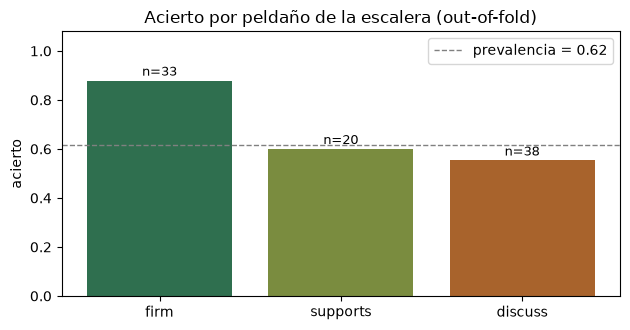

In [3]:
oof = pd.read_csv(ART / "expert_one_oof.csv")
tab = pd.DataFrame(ladder_table(oof["y"].values, oof["p_ensemble"].values, oof["sigma_total"].values))
tab["accuracy"] = tab["accuracy"].round(3); tab["coverage"] = tab["coverage"].round(3)
display(tab)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ok = tab["n"] > 0
ax.bar(tab.loc[ok, "rung"], tab.loc[ok, "accuracy"], color=["#2f6f4f", "#7a8c3f", "#a8632c"][: ok.sum()])
for i, (r, a, n) in enumerate(zip(tab.loc[ok, "rung"], tab.loc[ok, "accuracy"], tab.loc[ok, "n"])):
    ax.text(i, a + 0.02, f"n={n}", ha="center", fontsize=9)
ax.axhline(oof["y"].mean(), ls="--", c="grey", lw=1, label=f"prevalencia = {oof['y'].mean():.2f}")
ax.set_ylim(0, 1.08); ax.set_ylabel("acierto"); ax.set_title("Acierto por peldaño de la escalera (out-of-fold)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Calibración

Una probabilidad de 0.8 debería acertar 8 de cada 10 veces. La diagonal es el
ideal; la distancia media a ella es el ECE.

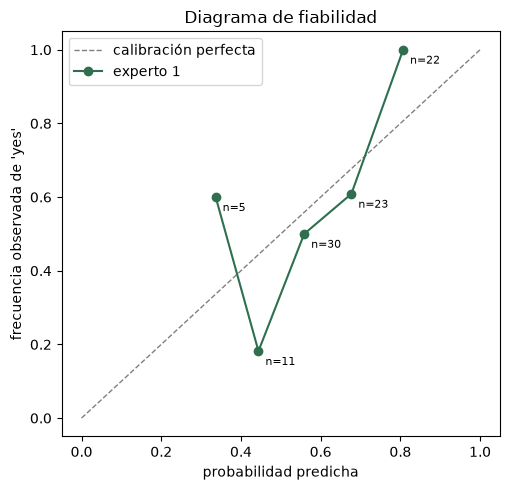

In [4]:
rel = pd.DataFrame(reliability_table(oof["y"].values, oof["p_ensemble"].values, n_bins=8)).dropna()
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="calibración perfecta")
ax.plot(rel["mean_predicted"], rel["observed_rate"], "o-", c="#2f6f4f", label="experto 1")
for _, r in rel.iterrows():
    ax.annotate(f"n={int(r['n'])}", (r["mean_predicted"], r["observed_rate"]), fontsize=8,
                textcoords="offset points", xytext=(5, -10))
ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia observada de 'yes'")
ax.set_title("Diagrama de fiabilidad"); ax.legend(); plt.tight_layout(); plt.show()

## 4. Dónde vive la incertidumbre

Dos ejes independientes. El horizontal es la probabilidad; el vertical, la
desviación epistémica total. Los casos que caen cerca de 0.5 con σ alta son
exactamente los que el experto manda a deliberación.

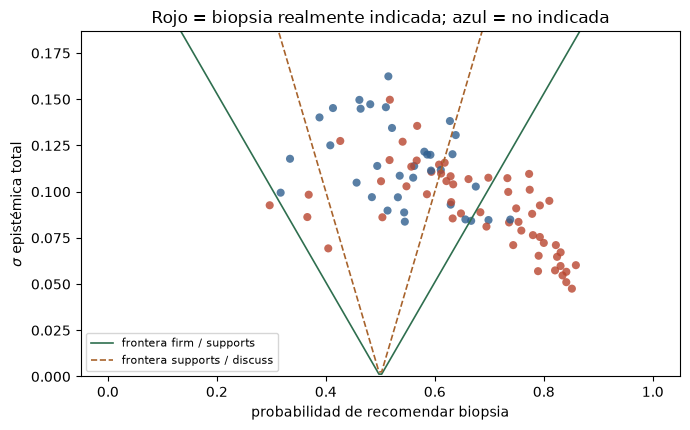

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.4))
col = np.where(oof["y"] == 1, "#b8452e", "#2f5f8f")
ax.scatter(oof["p_ensemble"], oof["sigma_total"], c=col, s=34, alpha=.8, edgecolor="none")
xs = np.linspace(0, 1, 200)
ax.plot(xs, np.abs(xs - .5) / 1.96, c="#2f6f4f", lw=1.2, label="frontera firm / supports")
ax.plot(xs, np.abs(xs - .5), c="#a8632c", lw=1.2, ls="--", label="frontera supports / discuss")
ax.set_xlabel("probabilidad de recomendar biopsia"); ax.set_ylabel(r"$\sigma$ epistémica total")
ax.set_ylim(0, max(oof["sigma_total"].max() * 1.15, .05))
ax.set_title("Rojo = biopsia realmente indicada; azul = no indicada")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. La incertidumbre por datos ausentes crece cuando faltan datos

Se toma un caso completo y se le van borrando variables. `epistemic_missing`
—el término *between-imputation* de las reglas de Rubin— tiene que subir de forma
monótona. Si no lo hiciera, el mecanismo no estaría haciendo su trabajo.

,variables borradas,p,sigma_modelo,sigma_ausencia,sigma_total,tramo
0,0,0.367,0.1428,0.0046,0.1429,discuss
1,2,0.401,0.1446,0.0050,0.1447,discuss
2,4,0.447,0.1496,0.0082,0.1498,discuss
3,6,0.434,0.1421,0.0121,0.1426,discuss
4,8,0.468,0.1325,0.0091,0.1329,discuss
5,10,0.615,0.1299,0.0144,0.1307,discuss
6,12,0.632,0.1200,0.0177,0.1213,supports
7,14,0.638,0.1277,0.0176,0.1289,supports
8,16,0.645,0.1316,0.0170,0.1327,supports
9,18,0.642,0.1282,0.0161,0.1292,supports


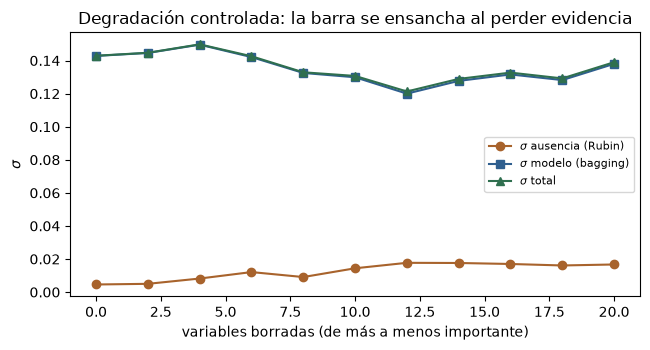

In [6]:
from chimera_experts.dataset import build_matrix
case = labelled[0]
X = expert._matrix([case])
order = [n for n, _ in sorted(expert.importance.items(), key=lambda kv: -kv[1]) if n in expert.feature_names]
idx   = [expert.feature_names.index(n) for n in order]

rows = []
for k in range(0, min(len(idx), 20) + 1, 2):
    Xk = X.copy(); Xk[0, idx[:k]] = np.nan
    v = expert.model.verdicts(Xk)[0]
    rows.append({"variables borradas": k, "p": round(v.probability, 3),
                 "sigma_modelo": round(v.epistemic_model, 4),
                 "sigma_ausencia": round(v.epistemic_missing, 4),
                 "sigma_total": round(v.epistemic_total, 4), "tramo": v.ladder})
deg = pd.DataFrame(rows); display(deg)

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(deg["variables borradas"], deg["sigma_ausencia"], "o-", c="#a8632c", label=r"$\sigma$ ausencia (Rubin)")
ax.plot(deg["variables borradas"], deg["sigma_modelo"],  "s-", c="#2f5f8f", label=r"$\sigma$ modelo (bagging)")
ax.plot(deg["variables borradas"], deg["sigma_total"],   "^-", c="#2f6f4f", label=r"$\sigma$ total")
ax.set_xlabel("variables borradas (de más a menos importante)"); ax.set_ylabel(r"$\sigma$")
ax.set_title("Degradación controlada: la barra se ensancha al perder evidencia")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Qué variables pesan, y cómo se traducen al formulario del reto

La importancia es la caída de AUC al permutar cada variable, medida fuera de la
partición de ajuste. Las columnas del modelo se agregan a las diez variables que
el formulario de CHIMERA puntúa.

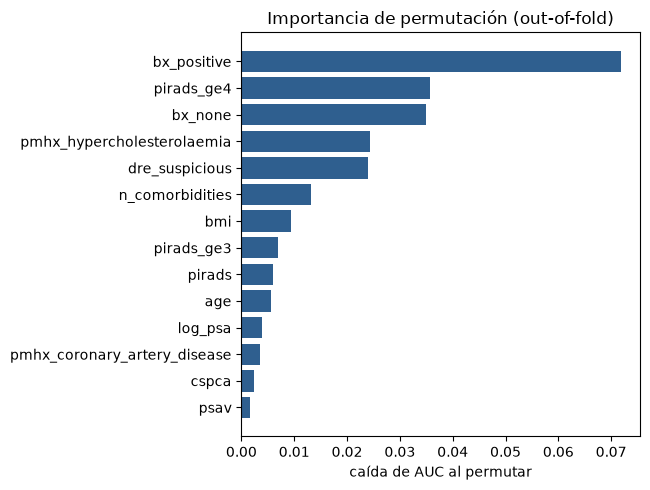

,variable del formulario,peso
0,age,noted
1,bx,decisive
2,comorbidity,important
3,cspca,noted
4,dre,noted
5,fh,not_used
6,pirads,noted
7,psa,noted
8,psad,noted
9,vol,noted


In [7]:
imp = pd.read_csv(ART / "expert_one_importance.csv").head(14)
fig, ax = plt.subplots(figsize=(6.6, 5))
ax.barh(imp["feature"][::-1], imp["auc_drop"][::-1], color="#2f5f8f")
ax.set_xlabel("caída de AUC al permutar"); ax.set_title("Importancia de permutación (out-of-fold)")
plt.tight_layout(); plt.show()

from chimera_experts.expert_classifier import weights_from_importance
display(pd.DataFrame(sorted(weights_from_importance(expert.importance, expert.blocks).items()),
                     columns=["variable del formulario", "peso"]))

## 7. Inferencia sobre un caso: la salida completa

Esto es lo que el experto entrega al deliberador. Los dos primeros ficheros son
exactamente los que el reto espera; el tercero es la carga ampliada con la
incertidumbre cruda, para que un agente posterior sepa cuánto fiarse.

In [8]:
rep = expert.report([labelled[3]])[0]
print("prostate-biopsy-decision.json  ->", json.dumps(rep.to_chimera_decision()))
print("\nprostate-biopsy-decision-reasoning.json:")
print(json.dumps(rep.to_chimera_reasoning(), indent=2, ensure_ascii=False))
print("\ncarga ampliada del experto:")
print(json.dumps(rep.to_expert_payload(), indent=2, ensure_ascii=False))

prostate-biopsy-decision.json  -> "yes"

prostate-biopsy-decision-reasoning.json:
{
  "confidence": "clear",
  "variable_weights": {
    "bx": "decisive",
    "fh": "not_used",
    "age": "noted",
    "dre": "noted",
    "psa": "noted",
    "vol": "noted",
    "psad": "noted",
    "cspca": "noted",
    "pirads": "noted",
    "comorbidity": "important"
  },
  "reveal_sequence": [],
  "free_text": "Modelo expert_one_structured sobre PI-RADS 5; PSA 5.9 ng/mL; densidad de PSA 0.199 ng/mL/mL; volumen prostático 29.71 mL; tacto rectal Normal; biopsia previa None. Probabilidad de recomendación de biopsia 0.87 (IC 95 % epistémico 0.72-1.00); se recomienda biopsia. El intervalo epistémico no cruza el umbral de decisión, de modo que el modelo sostiene este veredicto por sí solo."
}

carga ampliada del experto:
{
  "case_id": "PT-pseudo_033f1a8e1503",
  "expert": "expert_one_structured",
  "blocks": "A",
  "decision": "yes",
  "probability": 0.8683,
  "interval_95": [
    0.7241,
    1.0
  ],
  "

## 8. Los 195 casos, incluidos los 104 sin ground truth

El experto se aplica a toda la cohorte. Los casos sin etiqueta son los que el
reto evaluará: aquí se ve cómo se reparten entre los tres tramos de fiabilidad.

In [9]:
reports = expert.report(cases)
df = pd.DataFrame([{"case_id": r.case_id, "decision": r.to_chimera_decision(),
                    "p": round(r.verdict.probability, 3), "sigma": round(r.verdict.epistemic_total, 3),
                    "tramo": r.verdict.ladder, "confidence": r.verdict.confidence,
                    "etiquetado": c.has_label} for r, c in zip(reports, cases)])
display(pd.crosstab(df["tramo"], df["etiquetado"], margins=True))
display(pd.crosstab(df["tramo"], df["decision"]))
df.head(12)

etiquetado,False,True,All
tramo,,,
discuss,55,36,91
firm,23,37,60
supports,26,18,44
All,104,91,195


decision,no,yes
tramo,,
discuss,41,50
firm,2,58
supports,14,30


,case_id,decision,p,sigma,tramo,confidence,etiquetado
0,PT-pseudo_0020cfca66c8,no,0.367,0.140,discuss,uncertain,True
1,PT-pseudo_0169468160c6,yes,0.528,0.206,discuss,uncertain,True
2,PT-pseudo_01b643727538,yes,0.519,0.178,discuss,uncertain,True
3,PT-pseudo_033f1a8e1503,yes,0.868,0.074,firm,clear,True
4,PT-pseudo_0615b2bd8504,no,0.398,0.183,discuss,uncertain,True
5,PT-pseudo_062a1125899d,yes,0.781,0.120,firm,clear,True
6,PT-pseudo_06b319f42fcb,yes,0.789,0.126,firm,clear,True
7,PT-pseudo_075dd468b384,yes,0.536,0.162,discuss,uncertain,True
8,PT-pseudo_079636ac5644,no,0.437,0.180,discuss,uncertain,True
9,PT-pseudo_0930885168c9,no,0.448,0.165,discuss,uncertain,True
